# **Taller 2 - Diseño de Dashboard Analítico**

> ### Maestria en Ciencia de Datos y Analítica
> ### Visualización de Datos
> #### Sara Rendon, Yeison Londoño, Heider Zapata, Kelly Enriquez


## **Contexto del problema**

Dataset: eCommerce Behavior Data (REES46, Oct 2019)

Las plataformas de e-commerce enfrentan un reto estructural: la gran mayoría de 
los usuarios que visitan un producto nunca llegan a comprarlo. Las tasas de 
conversión promedio de la industria oscilan entre el 1% y el 3%, lo que significa 
que por cada 100 visitas, 97 se van sin generar valor.

Este notebook documenta el proceso completo de análisis: desde la exploración 
inicial de los datos hasta la construcción de un argumento visual aclaratorio 
orientado a la toma de decisiones de negocio.

## **Pregunta de Negocio**

> **¿En qué categorías de productos existe la mayor brecha entre intención de 
> compra y conversión efectiva, y qué factores (precio, marca, momento del día) 
> están asociados a esa brecha?**

Esta pregunta es relevante porque permite identificar dónde concentrar los 
esfuerzos de marketing e incentivos, en lugar de aplicar descuentos de forma 
indiscriminada a todos los usuarios.

## **Hipótesis**

Antes de explorar los datos, planteamos las siguientes suposiciones basadas en 
conocimiento del dominio de e-commerce:

**H1 — Brecha por categoría:** La tasa de conversión (view → purchase) no es 
uniforme entre categorías. Esperamos que productos de alto precio (electrónica) 
acumulen mucha intención de compra (carts) pero conviertan poco, mientras que 
categorías de precio medio tengan mejor conversión.

**H2 — Patrón temporal:** Las compras no se distribuyen uniformemente durante 
el día ni la semana. Esperamos encontrar picos en horarios específicos que 
sugieran ventanas óptimas para activar incentivos.

**H3 — El precio como barrera:** A mayor precio promedio de una categoría, 
menor será su tasa de conversión. El precio es el principal freno entre la 
intención y la compra efectiva.

---
*Estas hipótesis serán confirmadas, refutadas o matizadas por el EDA*

## **Generación de muestra del dataset completo**

In [1]:
#pip install duckdb

In [2]:
# import duckdb
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

In [3]:
# Instalar la librería gdown si es necesario
# !pip install --upgrade gdown

# import gdown
# import os

# # 2. Configuración del ID del archivo y la URL de descarga
# FILE_ID = '1kDasOXgXimvPn2Shu3wgZymbqj4_8pDc'  
# url = f'https://drive.google.com/uc?id={FILE_ID}'
# output_file = '2019-Oct.csv'

# # 3. Descargar el archivo solo si no existe localmente (para evitar descargas repetidas)
# if not os.path.exists(output_file):
#     print("Iniciando la descarga del dataset de 5GB desde Google Drive...")
#     # gdown se encarga de gestionar la advertencia de tamaño de Google
#     gdown.download(url, output_file, quiet=False)
#     print("¡Descarga completada!")
# else:
#     print("El archivo ya existe en el entorno local.")

Se realiza un muestreo aleatorio del dataset oct 2019, buscando obtener una muestra de 500000 filas.

In [4]:
# con = duckdb.connect()

# # Query para traer:
# # 1. El 100% de los eventos 'purchase' y 'cart'
# # 2. Solo un 2% de los eventos 'view' para no saturar la memoria
# query = """
#     SELECT * FROM read_csv_auto('2019-Oct.csv') 
#     USING SAMPLE 500000;
# """

# # Ejecutamos y guardamos en un DataFrame de Pandas
# df_muestra = con.execute(query).df()

# print(f"Tamaño de la muestra: {len(df_muestra)} filas")
# print(df_muestra['event_type'].value_counts())

Este fue el resultado de hacer un muestrero aleatorio de 500000 registros de la base de datos 2019-Oct.csv

- Tamaño de la muestra: 500000 filas
event_type
- view        480542
- cart         10851
- purchase      8607
- Name: count, dtype: int64

In [5]:
#df_muestra.to_csv('muestra_eventos.csv', index=False)

## **Carga de Datos**

Cargamos la muestra de 500,000 eventos del dataset REES46 (octubre 2019). 
Esta muestra fue obtenida mediante muestreo aleatorio simple del archivo 
original de ~5GB, preservando la distribución natural de eventos.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente para toda la exploración
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

# ── Carga de la muestra ──────────────────────────────────────────────────────
df_muestra = pd.read_csv('./raw/muestra_eventos_def.csv', parse_dates=['event_time'])

# ── Verificación rápida ───────────────────────────────────────────────────────
print(f"Dataset cargado: {df_muestra.shape[0]:,} filas × {df_muestra.shape[1]} columnas")
print(f"\nDistribución de eventos:")
print(df_muestra['event_type'].value_counts())

Dataset cargado: 500,000 filas × 9 columnas

Distribución de eventos:
event_type
view        480542
cart         10851
purchase      8607
Name: count, dtype: int64


In [7]:
df_muestra.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-16 14:47:46,view,25600036,2053013559675191951,NaN,mart,270.25,520700334,cf4b59d7-51ce-4235-bff1-2e023521d038
1,2019-10-31 11:06:12,view,1005115,2053013555631882655,electronics.smartphone,apple,952.37,529546123,1c0ab992-d849-4cfb-9c52-44ee750ebe6e
2,2019-10-24 10:33:09,view,1004227,2053013555631882655,electronics.smartphone,apple,1002.57,546385140,e5953cd4-124a-4341-b3e4-95c7933f42cc
3,2019-10-11 10:14:00,view,23300386,2053013561956893455,NaN,arua,30.86,551689123,a21706f9-7631-4ff0-a7d1-eee00d45acf6
4,2019-10-20 09:07:45,view,1005014,2053013555631882655,electronics.smartphone,samsung,544.38,558151232,47c24ba5-1cb4-4d4e-bb80-42ab2006ae6b


## **1. Inspección y Calidad de los Datos**

Antes de cualquier análisis, verificamos la estructura del dataset, los tipos 
de datos, valores nulos y posibles inconsistencias. Este paso es fundamental 
para garantizar que los hallazgos del EDA sean confiables.

In [8]:
# ── Estructura general ────────────────────────────────────────────────────────
print("=" * 55)
print("ESTRUCTURA DEL DATASET")
print("=" * 55)
print(df_muestra.info())

# ── Valores nulos ─────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("VALORES NULOS")
print("=" * 55)
missing = pd.DataFrame({
    'Nulos': df_muestra.isnull().sum(),
    'Porcentaje (%)': (df_muestra.isnull().sum() / len(df_muestra) * 100).round(2)
})
print(missing[missing['Nulos'] > 0])

# ── Duplicados ────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("DUPLICADOS")
print("=" * 55)
duplicados = df_muestra.duplicated().sum()
print(f"Filas duplicadas: {duplicados:,} ({duplicados/len(df_muestra)*100:.2f}%)")

# ── Valores únicos por columna categórica ────────────────────────────────────
print("\n" + "=" * 55)
print("VALORES ÚNICOS (columnas categóricas)")
print("=" * 55)
for col in ['event_type', 'brand', 'category_code']:
    print(f"{col}: {df_muestra[col].nunique():,} valores únicos")

# ── Rango de precios ──────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("RANGO DE PRECIOS")
print("=" * 55)
print(df_muestra['price'].describe())

ESTRUCTURA DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   event_time     500000 non-null  datetime64[us]
 1   event_type     500000 non-null  str           
 2   product_id     500000 non-null  int64         
 3   category_id    500000 non-null  int64         
 4   category_code  341012 non-null  str           
 5   brand          427912 non-null  str           
 6   price          500000 non-null  float64       
 7   user_id        500000 non-null  int64         
 8   user_session   500000 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(3), str(4)
memory usage: 34.3 MB
None

VALORES NULOS
                Nulos  Porcentaje (%)
category_code  158988           31.80
brand           72088           14.42

DUPLICADOS
Filas duplicadas: 11 (0.00%)

VALORES ÚNICOS (columnas categóricas)
event_type: 3 

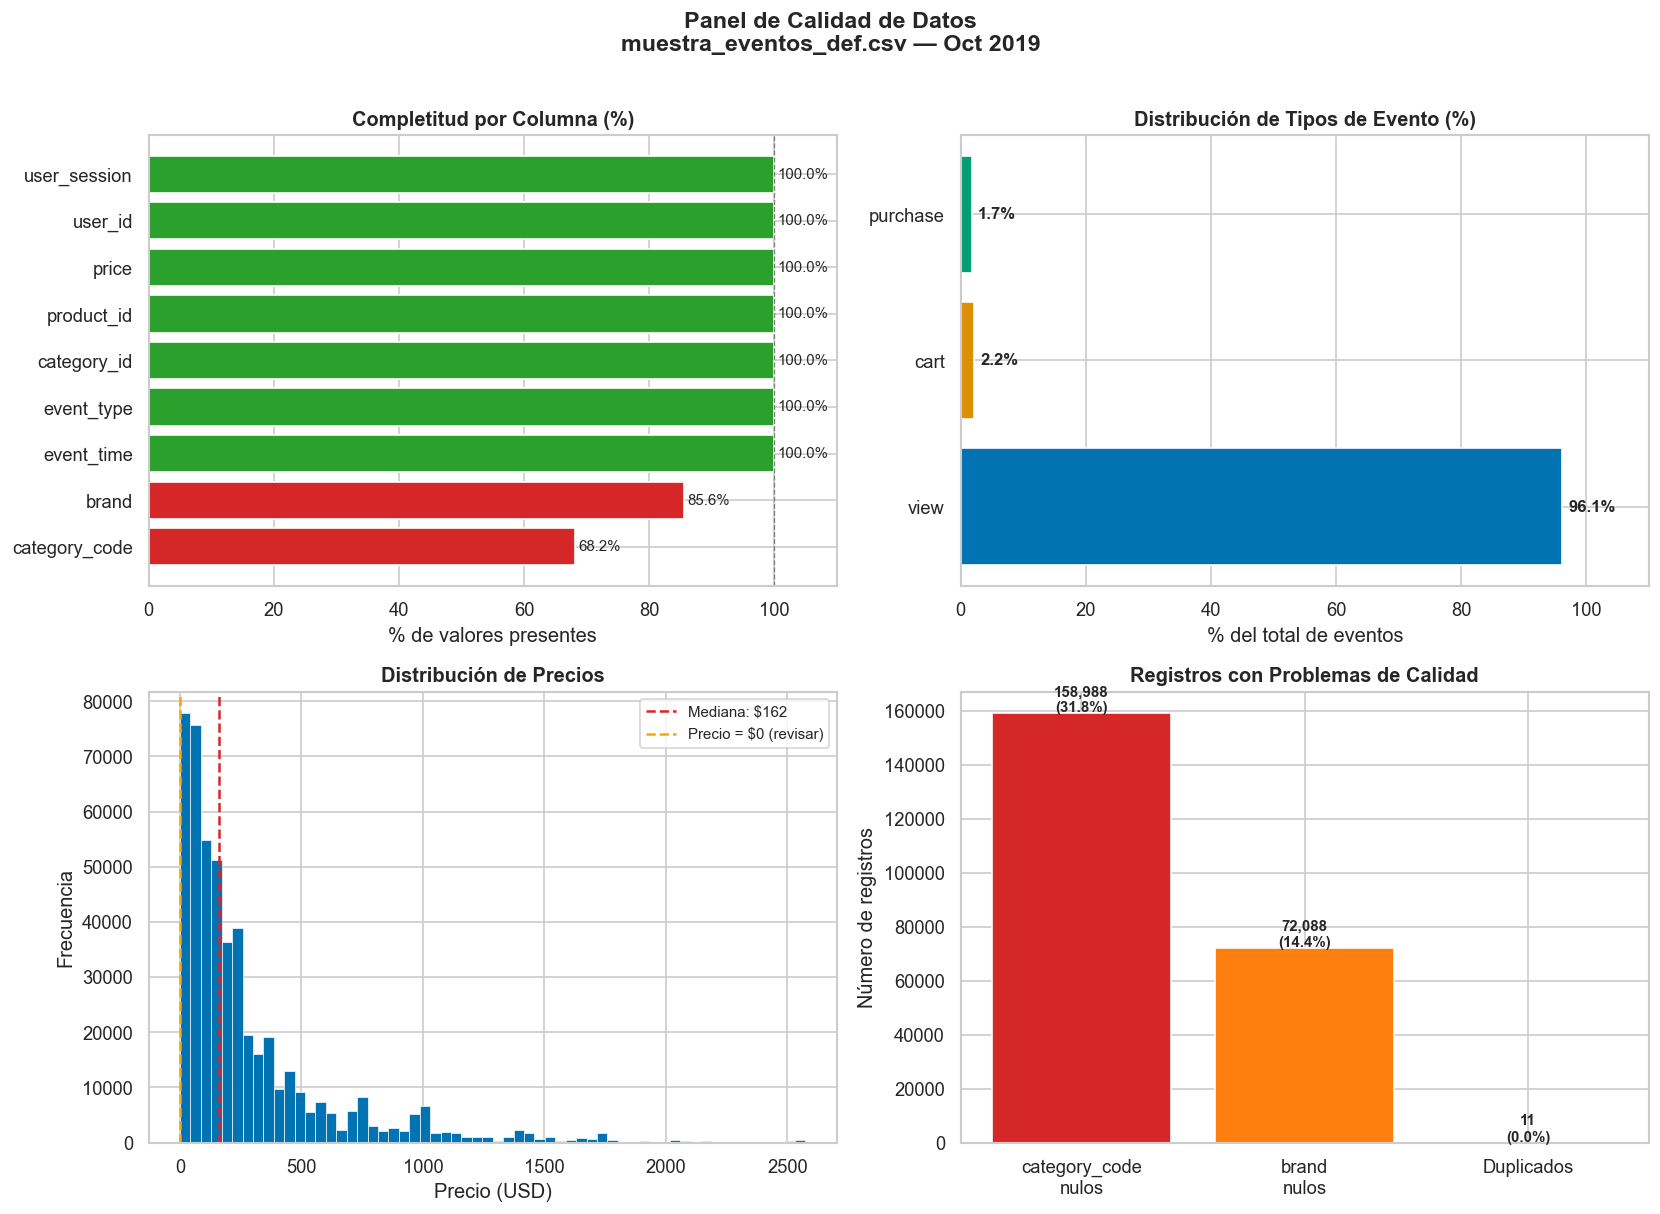

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Panel de Calidad de Datos\nmuestra_eventos_def.csv — Oct 2019',
             fontsize=14, fontweight='bold', y=1.01)

# ── Gráfico 1 (arriba izquierda): Completitud por columna ────────────────────
completitud = (df_muestra.notnull().sum() / len(df_muestra) * 100).sort_values()
colores_comp = ['#d62728' if v < 90 else '#2ca02c' for v in completitud]

axes[0, 0].barh(completitud.index, completitud.values, color=colores_comp)
axes[0, 0].set_xlim(0, 110)
axes[0, 0].axvline(100, color='gray', linestyle='--', linewidth=0.8)
axes[0, 0].set_title('Completitud por Columna (%)', fontweight='bold')
axes[0, 0].set_xlabel('% de valores presentes')
for i, v in enumerate(completitud.values):
    axes[0, 0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

# ── Gráfico 2 (arriba derecha): Distribución de eventos ─────────────────────
event_counts = df_muestra['event_type'].value_counts()
event_pct = (event_counts / len(df_muestra) * 100).round(2)

bars = axes[0, 1].barh(event_pct.index, event_pct.values,
                        color=sns.color_palette('colorblind', 3))
axes[0, 1].set_xlim(0, 110)
axes[0, 1].set_title('Distribución de Tipos de Evento (%)', fontweight='bold')
axes[0, 1].set_xlabel('% del total de eventos')

for bar, val in zip(bars, event_pct.values):
    axes[0, 1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
        
# ── Gráfico 3 (abajo izquierda): Distribución de precios ────────────────────
axes[1, 0].hist(df_muestra['price'], bins=60, color=sns.color_palette('colorblind')[0],
                edgecolor='white', linewidth=0.4)
axes[1, 0].axvline(df_muestra['price'].median(), color='#d62728', linestyle='--',
                   linewidth=1.5, label=f"Mediana: ${df_muestra['price'].median():.0f}")
axes[1, 0].axvline(0, color='orange', linestyle='--',
                   linewidth=1.5, label='Precio = $0 (revisar)')
axes[1, 0].set_title('Distribución de Precios', fontweight='bold')
axes[1, 0].set_xlabel('Precio (USD)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].legend(fontsize=9)

# ── Gráfico 4 (abajo derecha): Resumen de nulos y duplicados ────────────────
problemas = {
    'category_code\nnulos': 158988,
    'brand\nnulos': 72088,
    'Duplicados': 11
}
barras = axes[1, 1].bar(problemas.keys(), problemas.values(),
                         color=['#d62728', '#ff7f0e', '#2ca02c'])
axes[1, 1].set_title('Registros con Problemas de Calidad', fontweight='bold')
axes[1, 1].set_ylabel('Número de registros')
for bar, val in zip(barras, problemas.values()):
    pct = val / len(df_muestra) * 100
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                    f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('calidad_datos.png', bbox_inches='tight')
plt.show()

## **3. Limpieza de Datos**

Con base en la inspección anterior, aplicamos las siguientes decisiones:

- **Duplicados:** Se eliminan las 11 filas duplicadas.
- **Precios en cero:** Se eliminan — un precio de $0 no representa un evento 
  de compra real y distorsionaría el análisis de conversión.
- **`category_code` nulos:** Se **conservan**. El 31.8% de nulos es alto pero 
  estos registros siguen siendo válidos para analizar el funnel general. 
  Los filtraremos solo cuando el análisis requiera trabajar por categoría.
- **`brand` nulos:** Se **conservan** por la misma razón.

In [10]:
print(f"Filas antes de limpieza: {len(df_muestra):,}")

# ── Eliminar duplicados ───────────────────────────────────────────────────────
df_muestra = df_muestra.drop_duplicates()

# ── Eliminar precios en cero ─────────────────────────────────────────────────
precios_cero = (df_muestra['price'] == 0).sum()
df_muestra = df_muestra[df_muestra['price'] > 0]

print(f"Filas eliminadas por duplicado: 11")
print(f"Filas eliminadas por precio = $0: {precios_cero:,}")
print(f"Filas después de limpieza:  {len(df_muestra):,}")

Filas antes de limpieza: 500,000
Filas eliminadas por duplicado: 11
Filas eliminadas por precio = $0: 777
Filas después de limpieza:  499,212


> Después de la limpieza solo se perdió el 0.16% de la totalidad de los datos. Es un dataset sólido para trabajar.

## **4. Feature Engineering**

Derivamos nuevas variables a partir de las existentes para enriquecer el 
análisis. Todas se construyen sobre el dataset ya limpio.

- **`hour`**: Hora del evento — para analizar patrones de compra por franja horaria.
- **`day_of_week`**: Día de la semana — para identificar días de mayor conversión.
- **`date`**: Fecha sin hora — para análisis de tendencia diaria.
- **`category_main`**: Primer nivel de la jerarquía de categoría 
  (ej: `electronics.smartphone` → `electronics`).

In [12]:
df_muestra['hour']          = df_muestra['event_time'].dt.hour
df_muestra['day_of_week']   = df_muestra['event_time'].dt.day_name()
df_muestra['date']          = df_muestra['event_time'].dt.date
df_muestra['category_main'] = df_muestra['category_code'].str.split('.').str[0]

print("Variables derivadas agregadas:")
print(f"   • hour          → {df_muestra['hour'].nunique()} valores únicos (0–23)")
print(f"   • day_of_week   → {df_muestra['day_of_week'].nunique()} días")
print(f"   • date          → {df_muestra['date'].nunique()} fechas distintas")
print(f"   • category_main → {df_muestra['category_main'].nunique()} categorías principales")
print(f"\n Vista previa:")
print(df_muestra[['event_time','hour','day_of_week','category_main']].head(5))

Variables derivadas agregadas:
   • hour          → 24 valores únicos (0–23)
   • day_of_week   → 7 días
   • date          → 31 fechas distintas
   • category_main → 13 categorías principales

 Vista previa:
           event_time  hour day_of_week category_main
0 2019-10-16 14:47:46    14   Wednesday           NaN
1 2019-10-31 11:06:12    11    Thursday   electronics
2 2019-10-24 10:33:09    10    Thursday   electronics
3 2019-10-11 10:14:00    10      Friday           NaN
4 2019-10-20 09:07:45     9      Sunday   electronics
